# FSSK Signature Kernel — Validation

Validates `tensordev.kernel.fssk.fssk_sigkernel` against two independent reference implementations:

| Section | Reference | What is tested |
|---|---|---|
| **1** | VSig inner product | Kernel ≈ ⟨VSig_N(X), VSig_N(Y)⟩, converges as N→∞ |
| **2** | Naive Euler | Plain forward-Euler PDE scheme, first-order convergence as dt→0 |

Both references live in `validation/`.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('validation').resolve()))

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt

from tensordev.sss.kernel import FSSK
from tensordev.kernel.fssk import fssk_sigkernel
from tensordev.util.random_paths import random_trigonometric_polynomial_paths

from vsig_kernel_ref import vsig_kernel
from naive_euler import naive_euler_fssk_kernel

In [3]:
# ── Shared test setup ──────────────────────────────────────────────────────

dtype  = jnp.float64
d      = 3    # path dimension
n_path = 8    # batch size
steps  = 32   # time steps per path
T      = 1.0  # time horizon
dt     = T / steps

key_x = jr.PRNGKey(20260514)
key_y = jr.PRNGKey(20260515)
X = random_trigonometric_polynomial_paths(key_x, batch=n_path, steps=steps, dim=d)
Y = random_trigonometric_polynomial_paths(key_y, batch=n_path, steps=steps, dim=d)
print('X:', X.shape, '  Y:', Y.shape, '  dt:', dt)

X: (8, 33, 3)   Y: (8, 33, 3)   dt: 0.03125


In [4]:
# ── Test kernel (non-trivial Lambda) ──────────────────────────────────────
# Two real rates, one projection matrix, moderate state dimension.

rng    = np.random.default_rng(42)
R      = 2
Lambda = np.diag(rng.uniform(0.2, 1.5, size=R)).astype(np.float64)
A_mat  = rng.standard_normal((1, d, d)).astype(np.float64) * 0.5
b_vec  = rng.standard_normal((1, R)).astype(np.float64)

kernel = FSSK.from_matrix(
    Lambda=jnp.asarray(Lambda),
    A=jnp.asarray(A_mat),
    b=jnp.asarray(b_vec),
)
print('Lambda:', Lambda)
print('b:', b_vec)

Lambda: [[1.20614286 0.        ]
 [0.         0.77054197]]
b: [[0.77779194 0.0660307 ]]


## 1. VSig inner-product reference

The FSSK kernel admits the expansion
$$k(X,Y) = \sum_{n=0}^{\infty} \langle \mathrm{VSig}^n(X),\, \mathrm{VSig}^n(Y) \rangle$$
where $\mathrm{VSig}^n$ is the degree-$n$ Volterra signature computed via the exact SSS recursion.
Truncating at level $N$ gives a converging sequence of approximations.

We compare the pairwise Gram matrix from the production Heun scheme (`dyadic_order=4`) against the
VSig inner product at increasing truncation levels.

In [5]:
# Production reference: Heun at high dyadic order
K_ref = fssk_sigkernel(
    X, Y, kernel=kernel, dt_x=dt, dt_y=dt,
    evaluate='terminal', pairwise=True,
    backend='scan', scheme='heun', dyadic_order=6,
)
print('Reference Gram (Heun, dyadic=4):')
print(np.round(np.asarray(K_ref), 4))

Reference Gram (Heun, dyadic=4):
[[0.9957 0.9308 0.994  1.0499 1.0151 1.0506 1.0456 0.9903]
 [1.0068 0.9653 0.9993 1.0349 1.0084 1.0277 1.0033 0.9865]
 [1.0136 0.9977 0.9988 1.0271 0.9974 1.03   0.9898 0.9808]
 [0.9734 0.9734 0.999  0.9795 1.0103 0.995  1.0527 1.0344]
 [1.0192 0.903  1.0197 1.0656 1.0476 0.9291 0.9398 0.9857]
 [1.0114 0.9901 0.9996 1.0295 0.9983 1.0331 0.9972 0.9801]
 [0.9908 0.9482 0.9919 1.0305 1.0005 1.064  1.0637 0.9936]
 [1.0069 1.1196 1.0068 0.9517 0.9862 0.9402 0.9523 1.0173]]


In [6]:
trunc_levels = [4, 6, 8, 10, 12]
vsig_errors  = []

for N in trunc_levels:
    K_vsig = vsig_kernel(X, Y, kernel=kernel, dt_x=dt, dt_y=dt, trunc=N, pairwise=True)
    err = float(jnp.max(jnp.abs(K_vsig - K_ref)))
    vsig_errors.append(err)
    print(f'  trunc={N:2d}  max|K_vsig - K_ref| = {err:.3e}')

  trunc= 4  max|K_vsig - K_ref| = 6.322e-04
  trunc= 6  max|K_vsig - K_ref| = 8.410e-06
  trunc= 8  max|K_vsig - K_ref| = 9.683e-08
  trunc=10  max|K_vsig - K_ref| = 9.994e-08
  trunc=12  max|K_vsig - K_ref| = 9.996e-08


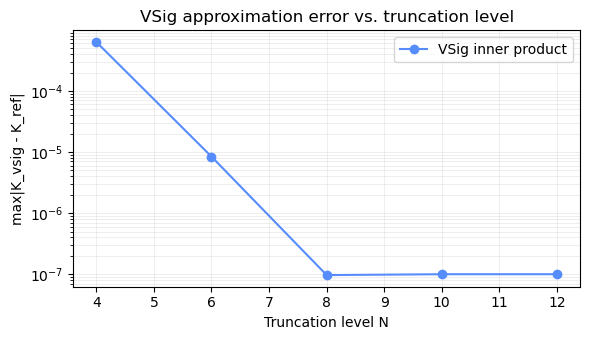

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(trunc_levels, vsig_errors, 'o-', label='VSig inner product')
ax.set_xlabel('Truncation level N')
ax.set_ylabel('max|K_vsig - K_ref|')
ax.set_title('VSig approximation error vs. truncation level')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 2. Naive Euler reference

The naive Euler scheme replaces the ETD1 matrix-exponential transport with a plain forward
Euler step ($e^{-\Lambda h} \approx I - \Lambda h$) and evaluates the area term at the NW
corner (rectangle rule). This gives **first-order** convergence in the step size.

We compare the naive Euler kernel values against the production Heun scheme as a function of
dyadic refinement order $k$ (each level halves the step size).

In [9]:
dyadic_orders = list(range(8))
euler_errors  = []

# Use a small subset for speed
Xc, Yc = X[:3], Y[:3]

K_ref_small = fssk_sigkernel(
    Xc, Yc, kernel=kernel, dt_x=dt, dt_y=dt,
    evaluate='terminal', pairwise=True,
    backend='scan', scheme='heun', dyadic_order=6,
)

for k in dyadic_orders:
    K_euler = naive_euler_fssk_kernel(
        Xc, Yc, kernel=kernel, dt_x=dt, dt_y=dt,
        pairwise=True, dyadic_order=k,
    )
    err = float(jnp.max(jnp.abs(K_euler - K_ref_small)))
    euler_errors.append(err)
    print(f'  dyadic={k}  step={dt/2**k:.4f}  max|K_euler - K_ref| = {err:.3e}')

  dyadic=0  step=0.0312  max|K_euler - K_ref| = 2.341e-02
  dyadic=1  step=0.0156  max|K_euler - K_ref| = 1.000e-02
  dyadic=2  step=0.0078  max|K_euler - K_ref| = 4.605e-03
  dyadic=3  step=0.0039  max|K_euler - K_ref| = 2.207e-03
  dyadic=4  step=0.0020  max|K_euler - K_ref| = 1.080e-03
  dyadic=5  step=0.0010  max|K_euler - K_ref| = 5.343e-04
  dyadic=6  step=0.0005  max|K_euler - K_ref| = 2.657e-04
  dyadic=7  step=0.0002  max|K_euler - K_ref| = 1.325e-04


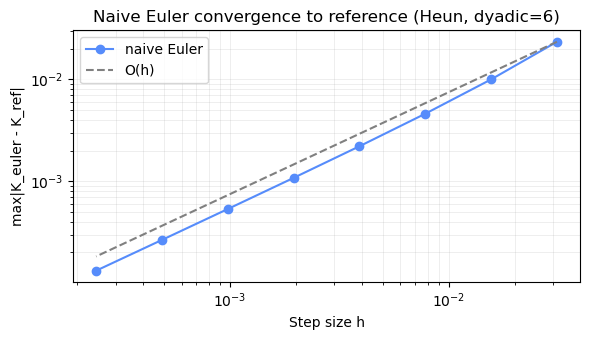

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))
steps_arr = np.array([dt / 2**k for k in dyadic_orders])
errs_arr  = np.array(euler_errors)

ax.loglog(steps_arr, errs_arr, 'o-', label='naive Euler')

# Overlay a reference O(h^1) slope
valid = errs_arr > 0
if valid.sum() >= 2:
    h0, e0 = steps_arr[valid][0], errs_arr[valid][0]
    hs_ref = np.array([steps_arr[valid][0], steps_arr[valid][-1]])
    ax.loglog(hs_ref, e0 * (hs_ref / h0), '--', color='gray', label='O(h)')

ax.set_xlabel('Step size h')
ax.set_ylabel('max|K_euler - K_ref|')
ax.set_title('Naive Euler convergence to reference (Heun, dyadic=6)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Cross-check: VSig reference vs Naive Euler at fine grid

At high truncation and fine step size the two references should agree with the production kernel.

In [ ]:
K_vsig_hi  = vsig_kernel(Xc, Yc, kernel=kernel, dt_x=dt, dt_y=dt, trunc=16, pairwise=True)
K_euler_hi = naive_euler_fssk_kernel(
    Xc, Yc, kernel=kernel, dt_x=dt, dt_y=dt, pairwise=True, dyadic_order=7
)

print('max|K_vsig(N=16) - K_ref|  :', float(jnp.max(jnp.abs(K_vsig_hi  - K_ref_small))))
print('max|K_euler(dy=7) - K_ref| :', float(jnp.max(jnp.abs(K_euler_hi - K_ref_small))))
print('max|K_vsig - K_euler|      :', float(jnp.max(jnp.abs(K_vsig_hi  - K_euler_hi))))